In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy.signal as sc
import xarray as xr
np.seterr(divide='ignore')
import numpy.ma as ma

In [32]:
def plot_C_all_Deltas(Cs, Cth, Cqt, z, z_i, labels_in, title, plot_dir, C_type = 'C', set_x_axis=None, Cs_IC = None, Cth_IC = None, Cqt_IC = None):

    colours = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple',
               'tab:cyan', 'tab:gray', 'tab:brown', 'tab:olive', 'tab:pink']


    fig, ax = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(15,6))

    fig.tight_layout(pad=0.5)

    for it in range(len(Cs[:,0])):
        if C_type == 'C':
            ax[0].plot(get_Cs(Cs[it,:]), z/z_i, color=colours[it], label='$\\widehat{\\bar{\\Delta}} = $'+labels_in[it])
            ax[1].plot(get_Cs(Cth[it, :]), z/z_i, color=colours[it], label='$\\widehat{\\bar{\\Delta}} = $'+labels_in[it])
            ax[2].plot(get_Cs(Cqt[it, :]), z/z_i, color=colours[it], label='$\\widehat{\\bar{\\Delta}} = $'+labels_in[it])

            if Cs_IC is not None:
                ax[0].plot(get_Cs(Cs_IC[it,:]), z/z_i, color=colours[it], linestyle='--')
                ax[1].plot(get_Cs(Cth_IC[it, :]), z/z_i, color=colours[it], linestyle='--')
                ax[2].plot(get_Cs(Cqt_IC[it, :]), z/z_i, color=colours[it], linestyle='--')

        elif C_type == 'C_new':
            ax[0].plot(new_get_Cs(Cs[it,:]), z/z_i, color=colours[it], label='$\\widehat{\\bar{\\Delta}} = $'+labels_in[it])
            ax[1].plot(new_get_Cs(Cth[it, :]), z/z_i, color=colours[it], label='$\\widehat{\\bar{\\Delta}} = $'+labels_in[it])
            ax[2].plot(new_get_Cs(Cqt[it, :]), z/z_i, color=colours[it], label='$\\widehat{\\bar{\\Delta}} = $'+labels_in[it])

        else:
            ax[0].plot(Cs[it,:], z/z_i, color=colours[it], label='$\\widehat{\\bar{\\Delta}} = $'+labels_in[it])
            ax[1].plot(Cth[it, :], z/z_i, color=colours[it], label='$\\widehat{\\bar{\\Delta}} = $'+labels_in[it])
            ax[2].plot(Cqt[it, :], z/z_i, color=colours[it], label='$\\widehat{\\bar{\\Delta}} = $'+labels_in[it])

    if C_type == 'C' or C_type == 'C_new':
        ax[0].set_xlabel('$C_{s}$'+f' {title}', fontsize=16)
        ax[1].set_xlabel('$C_{\\theta}$'+f' {title}', fontsize=16)
        ax[2].set_xlabel('$C_{qt}$'+f' {title}', fontsize=16)#
    else:
        ax[0].set_xlabel('$C_{s}^2$'+f' {title}', fontsize=16)
        ax[1].set_xlabel('$C_{\\theta}^2$'+f' {title}', fontsize=16)
        ax[2].set_xlabel('$C_{qt}^2$'+f' {title}', fontsize=16)

    # else:
    #     ax[0].set_xlabel('$C^2_{s}$', fontsize=16)
    #     ax[1].set_xlabel('$C^2_{\\theta}$', fontsize=16)
    #     ax[2].set_xlabel('$C^2_{qt}$', fontsize=16)
    ax[0].legend(fontsize=13, loc='upper right')
    ax[1].legend(fontsize=13, loc='upper right')
    ax[2].legend(fontsize=13, loc='best')


    left0, right0 = ax[0].set_xlim()
    left1, right1 = ax[1].set_xlim()
    left2, right2 = ax[2].set_xlim()

    set_right = max(right0, right1, right2)
    set_left = min(left0, left1, left2)

    if set_x_axis is not None:
        set_right = set_x_axis[1]
        set_left = set_x_axis[0]


    print('for all Delta profs, min is = ', set_left, 'max is =', set_right)

    ax[0].set_xlim(right = set_right, left = set_left)
    ax[1].set_xlim(right = set_right, left = set_left)
    ax[2].set_xlim(right = set_right, left = set_left)

    ax[0].set_ylim(bottom=0)
    ax[1].set_ylim(bottom=0)
    ax[2].set_ylim(bottom=0)

    ax[0].set_ylabel("z/z$_{ML}$ (z$_{ML}$ = "+ str(z_i) + "m)", fontsize=16)
    plt.savefig(plot_dir + f'BOMEX_{C_type}_{title}_all_Delta_prof_scaled_zn.png', bbox_inches='tight')
    plt.show()

    plt.close()

In [4]:
case = 'BOMEX'

In [5]:
partit = ['dom_av', 'NC', 'IC', 'CU', 'CC']

In [6]:
set_labels = ['4$\\Delta$', '8$\\Delta$', '16$\\Delta$', '32$\\Delta$', '64$\\Delta$', '128$\\Delta$']
deltas = ['4D', '8D', '16D', '32D', '64D', '128D']

In [7]:
arm_path = 'C:/Users/si818415/Documents/code/LES_analysis/data/ARM/'
bomex_path = 'C:/Users/si818415/Documents/code/LES_analysis/data/BOMEX/'

path='C:/Users/si818415/Documents/code/LES_analysis/data/'

plot_dir_BOMEX = 'C:/Users/si818415/Documents/plots/updated_C/BOMEX/C_profs/'
plot_dir_ARM = 'C:/Users/si818415/Documents/plots/updated_C/ARM/C_profs/'

In [8]:

dx_BOMEX=20
z_BOMEX = np.arange(0, 3020, 20)
z_i_BOMEX = 430 #1120

dx_ARM=25
z_ARM = np.arange(0, 4410, 10)
z_i_ARM = [795, 955, 1095, 1255]

In [9]:
C_sq_BOMEX_0 = np.load(bomex_path+f'C_sq_cond_14400_0.npy')
C_sq_BOMEX_1 = np.load(bomex_path+f'C_sq_cond_14400_1.npy')

C_sq_ARM_18000_0 = np.load(arm_path+f'C_sq_cond_18000_0.npy')
C_sq_ARM_25200_0 = np.load(arm_path+f'C_sq_cond_25200_0.npy')
C_sq_ARM_32400_0 = np.load(arm_path+f'C_sq_cond_32400_0.npy')
C_sq_ARM_39600_0 = np.load(arm_path+f'C_sq_cond_39600_0.npy')

C_sq_ARM_18000_1 = np.load(arm_path+f'C_sq_cond_18000_1.npy')
C_sq_ARM_25200_1 = np.load(arm_path+f'C_sq_cond_25200_1.npy')
C_sq_ARM_32400_1 = np.load(arm_path+f'C_sq_cond_32400_1.npy')
C_sq_ARM_39600_1 = np.load(arm_path+f'C_sq_cond_39600_1.npy')

In [10]:
def get_Cs(Cs_sq):
    """ calculates C_s from C_s^2 by setting neg values to zero
    and sq rooting"""

    Cs_sq_copy = Cs_sq.copy()
    Cs_sq_copy[Cs_sq < 0] = 0
    Cs = np.sqrt(Cs_sq_copy)

    return Cs

In [11]:
def new_get_Cs(Cs_sq):
    """ calculates C_s from C_s^2 by setting neg values to zero
    and sq rooting"""

    Cs_sq_copy = Cs_sq.copy()
    Cs_sq_copy[Cs_sq < 0] = - Cs_sq[Cs_sq < 0]
    Cs = np.sqrt(Cs_sq_copy)

    return Cs

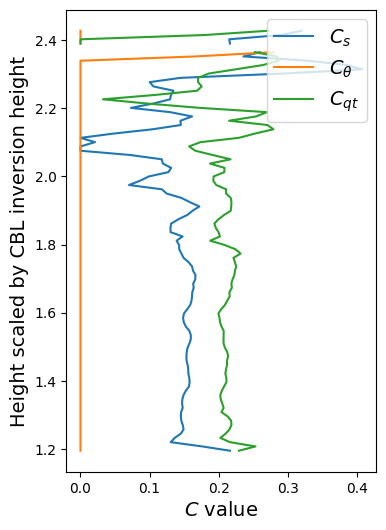

In [12]:
p=4
d=0

plt.figure(figsize=(4,6))
# plt.title(f'{case} C CC profs at res 4D')
plt.plot(get_Cs(C_sq_ARM_25200_0)[0,p,d,:], z_ARM/z_i_ARM[0], label='$C_s$')
plt.plot(get_Cs(C_sq_ARM_25200_0)[1,p,d,:], z_ARM/z_i_ARM[0], label='$C_\\theta$')
plt.plot(get_Cs(C_sq_ARM_25200_0)[2,p,d,:], z_ARM/z_i_ARM[0], label='$C_{qt}$')
plt.legend(loc='upper right', fontsize=14)
plt.xlabel('$C$ value', size=14)
plt.ylabel('Height scaled by CBL inversion height', size=14)
plt.savefig(f'{plot_dir_ARM}{case}_25200_C_{partit[p]}_profs_{deltas[d]}.pdf', bbox_inches='tight')

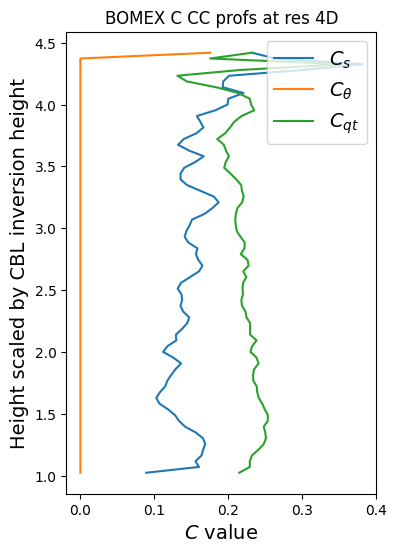

In [13]:
plt.figure(figsize=(4,6))
plt.title(f'{case} C CC profs at res 4D')
plt.plot(get_Cs(C_sq_BOMEX_0)[0,4,0,:], z_BOMEX/z_i_BOMEX, label='$C_s$')
plt.plot(get_Cs(C_sq_BOMEX_0)[1,4,0,:], z_BOMEX/z_i_BOMEX, label='$C_\\theta$')
plt.plot(get_Cs(C_sq_BOMEX_0)[2,4,0,:], z_BOMEX/z_i_BOMEX, label='$C_{qt}$')
plt.legend(loc='upper right', fontsize=14)
plt.xlabel('$C$ value', size=14)
plt.ylabel('Height scaled by CBL inversion height', size=14)
plt.savefig(f'{plot_dir_BOMEX}{case}_C_CC_profs_4D.pdf', bbox_inches='tight')

for all Delta profs, min is =  -0.010170026794437676 max is = 0.2135705626831912


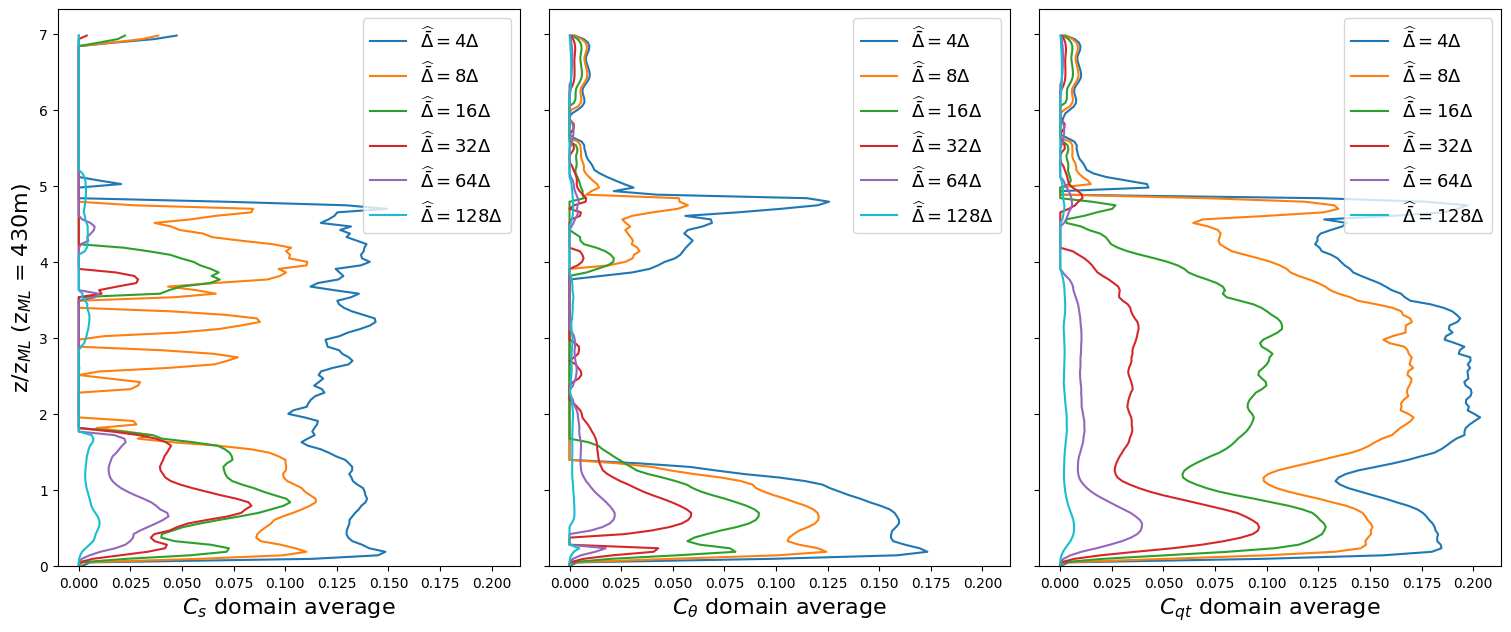

In [14]:
plot_C_all_Deltas(C_sq_BOMEX_0[0,0,...], C_sq_BOMEX_0[1,0,...], C_sq_BOMEX_0[2,0,...], z_BOMEX, z_i_BOMEX, set_labels, 'domain average', plot_dir_BOMEX)

for all Delta profs, min is =  -0.009233039414693006 max is = 0.1938938277085531


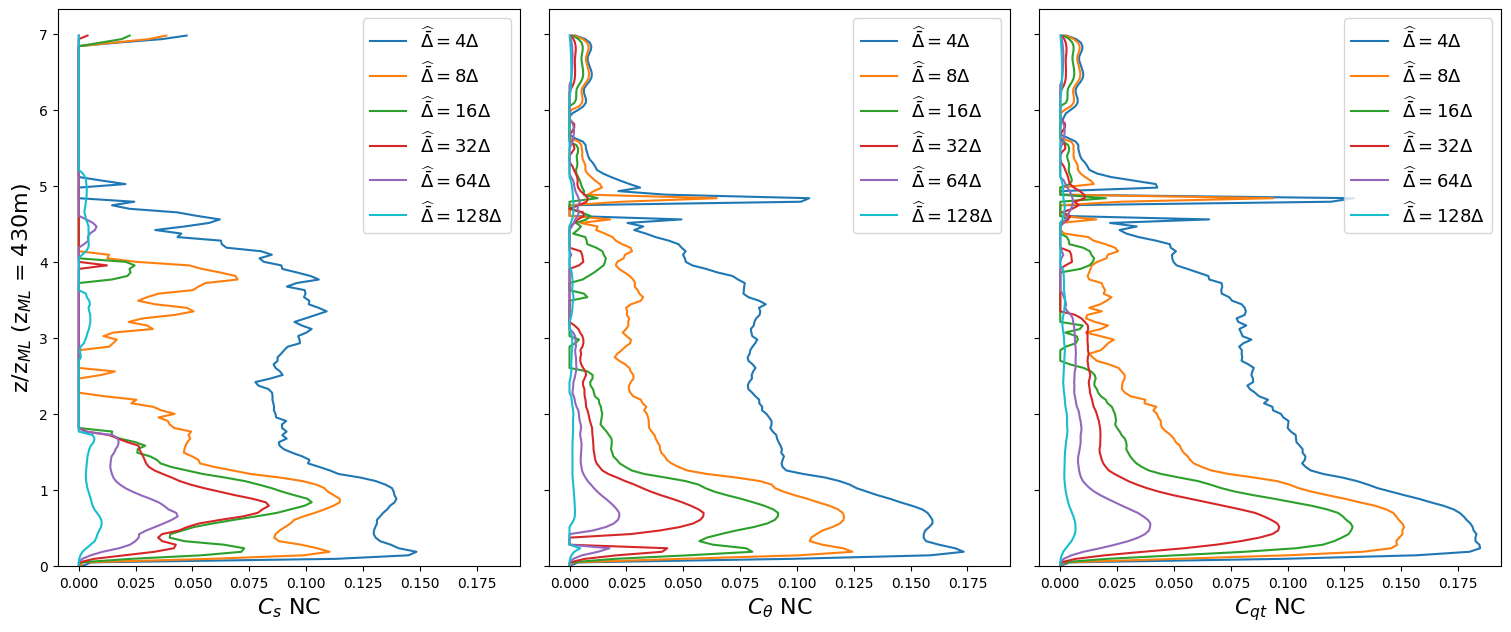

In [15]:
plot_C_all_Deltas(C_sq_BOMEX_0[0,1,...], C_sq_BOMEX_0[1,1,...], C_sq_BOMEX_0[2,1,...], z_BOMEX, z_i_BOMEX, set_labels, 'NC', plot_dir_BOMEX)

for all Delta profs, min is =  -0.011686737779984305 max is = 0.2454214933796704


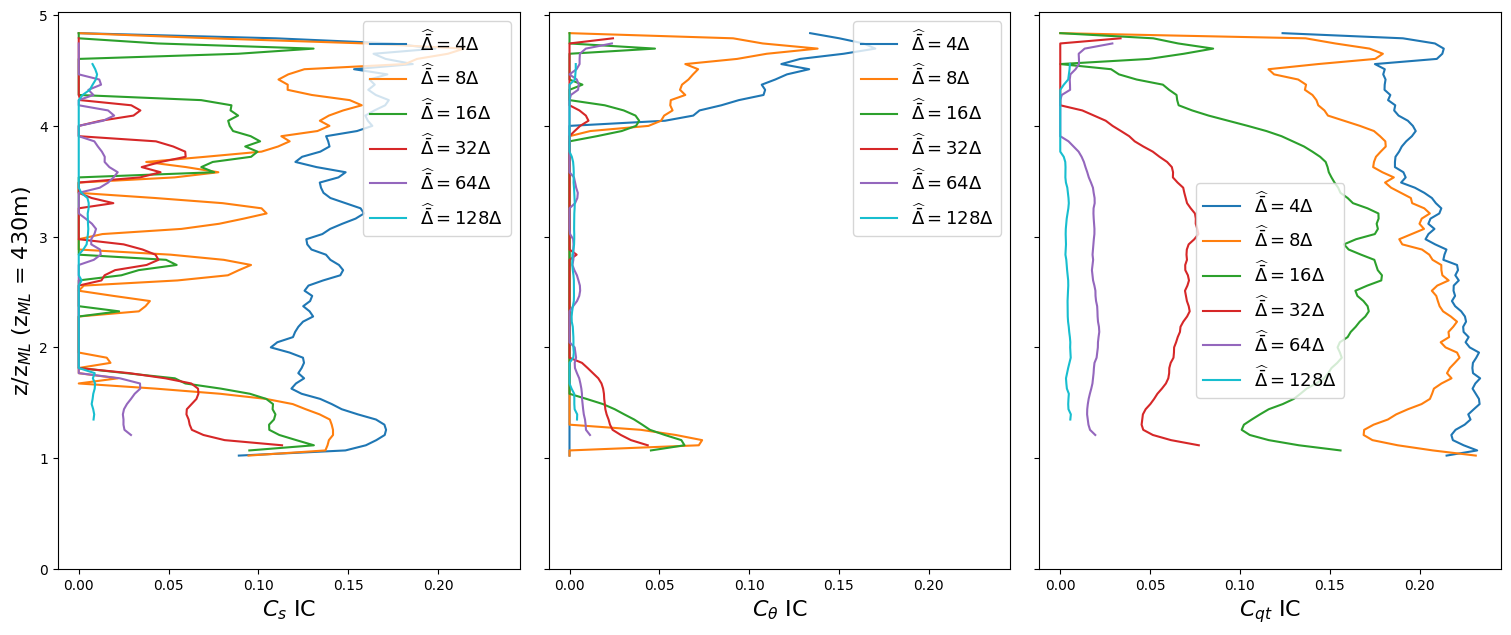

In [16]:
plot_C_all_Deltas(C_sq_BOMEX_0[0,2,...], C_sq_BOMEX_0[1,2,...], C_sq_BOMEX_0[2,2,...], z_BOMEX, z_i_BOMEX, set_labels, 'IC', plot_dir_BOMEX)

for all Delta profs, min is =  -0.04811543252687287 max is = 0.05796444681406858


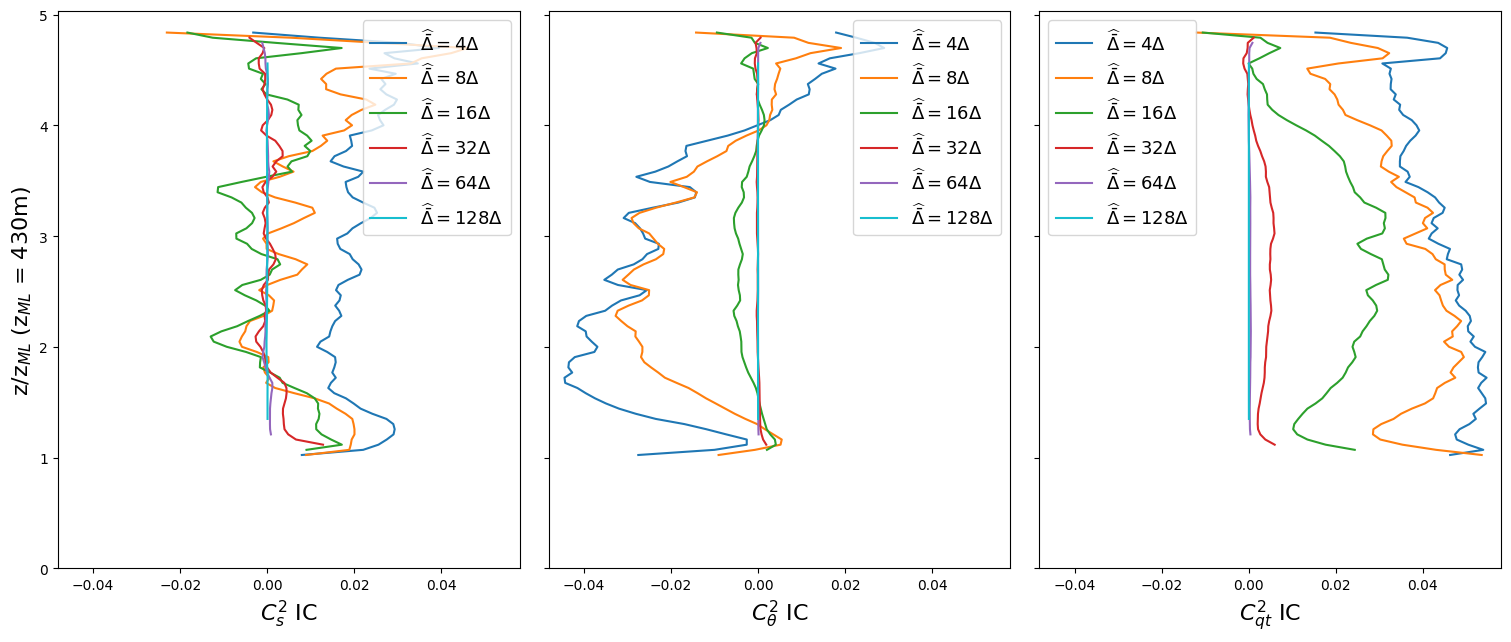

In [17]:
plot_C_all_Deltas(C_sq_BOMEX_0[0,2,...], C_sq_BOMEX_0[1,2,...], C_sq_BOMEX_0[2,2,...], z_BOMEX, z_i_BOMEX, set_labels, 'IC', plot_dir_BOMEX, C_type = 'C_sq',)

for all Delta profs, min is =  -0.010973455261260418 max is = 0.24538752754544546


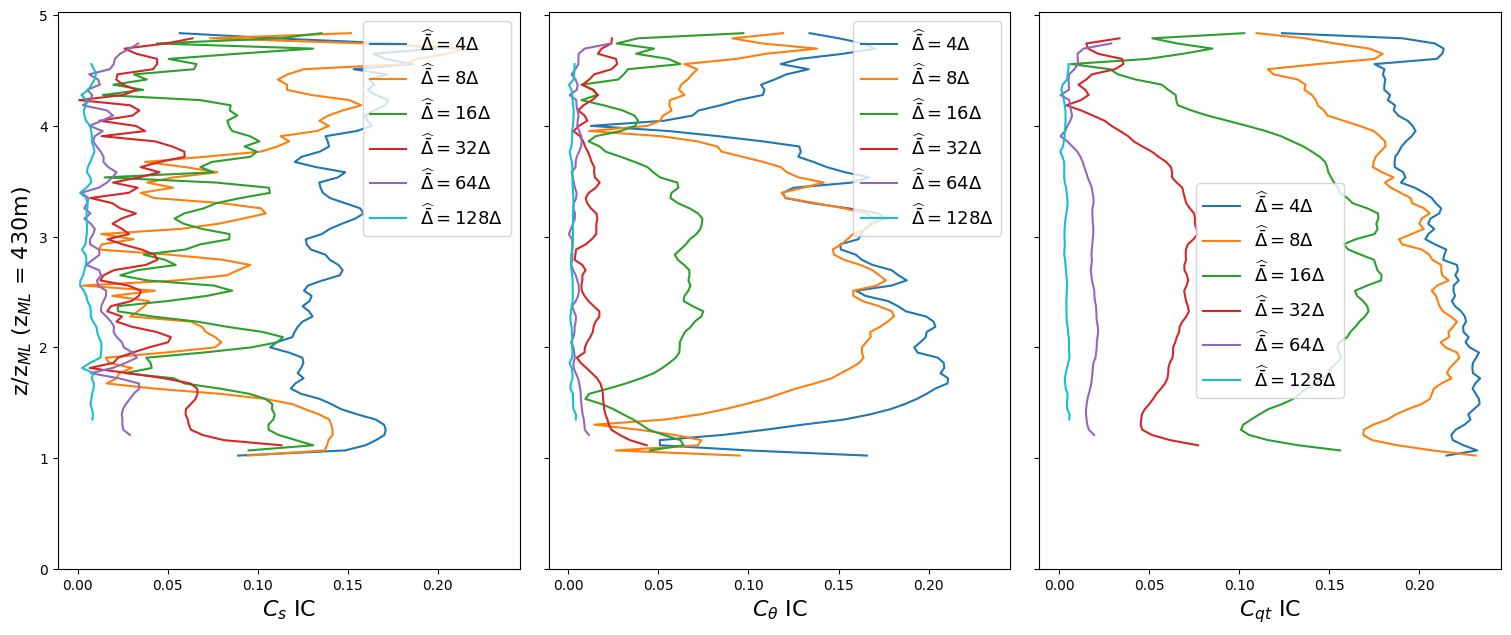

In [33]:
plot_C_all_Deltas(C_sq_BOMEX_0[0,2,...], C_sq_BOMEX_0[1,2,...], C_sq_BOMEX_0[2,2,...], z_BOMEX, z_i_BOMEX, set_labels, 'IC', plot_dir_BOMEX, C_type = 'C_new',)

for all Delta profs, min is =  -0.08 max is = 0.1


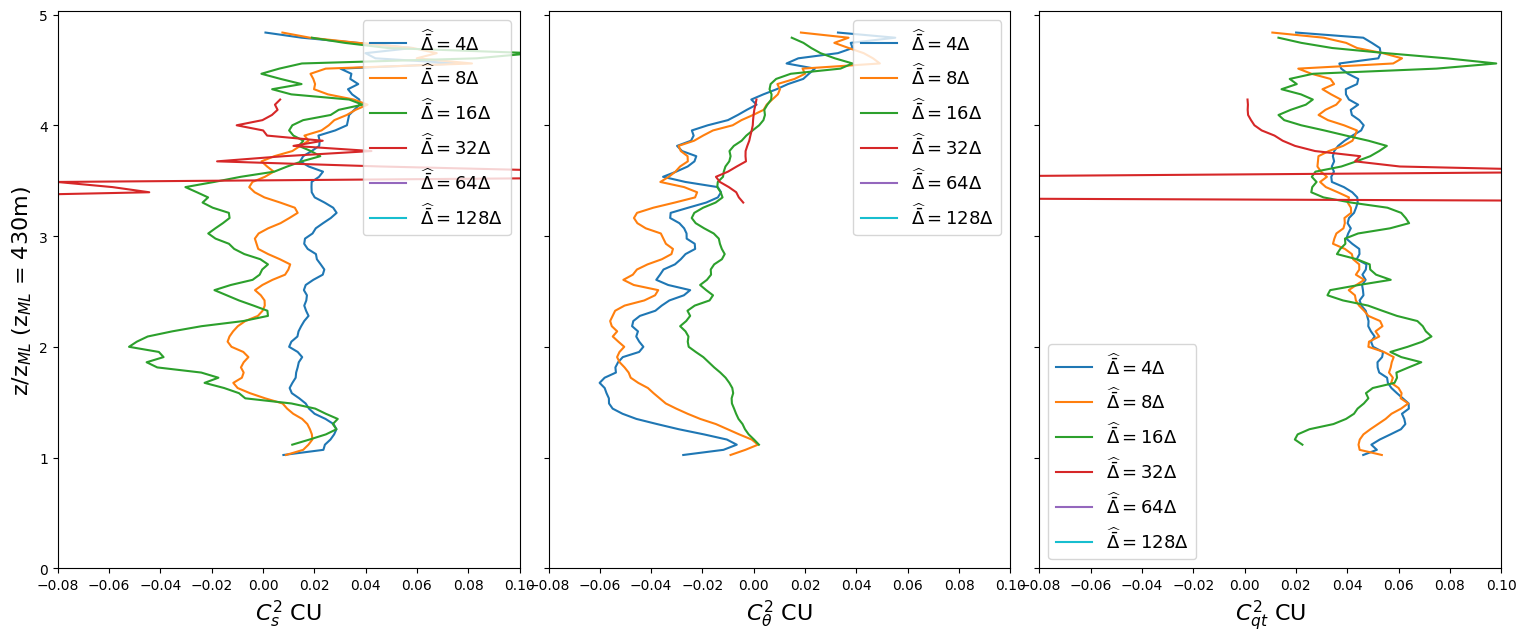

In [18]:
plot_C_all_Deltas(C_sq_BOMEX_0[0,3,...], C_sq_BOMEX_0[1,3,...], C_sq_BOMEX_0[2,3,...], z_BOMEX, z_i_BOMEX,
                  set_labels, 'CU', plot_dir_BOMEX, C_type = 'C_sq', set_x_axis = [-0.08, 0.1])

for all Delta profs, min is =  -0.01 max is = 0.3


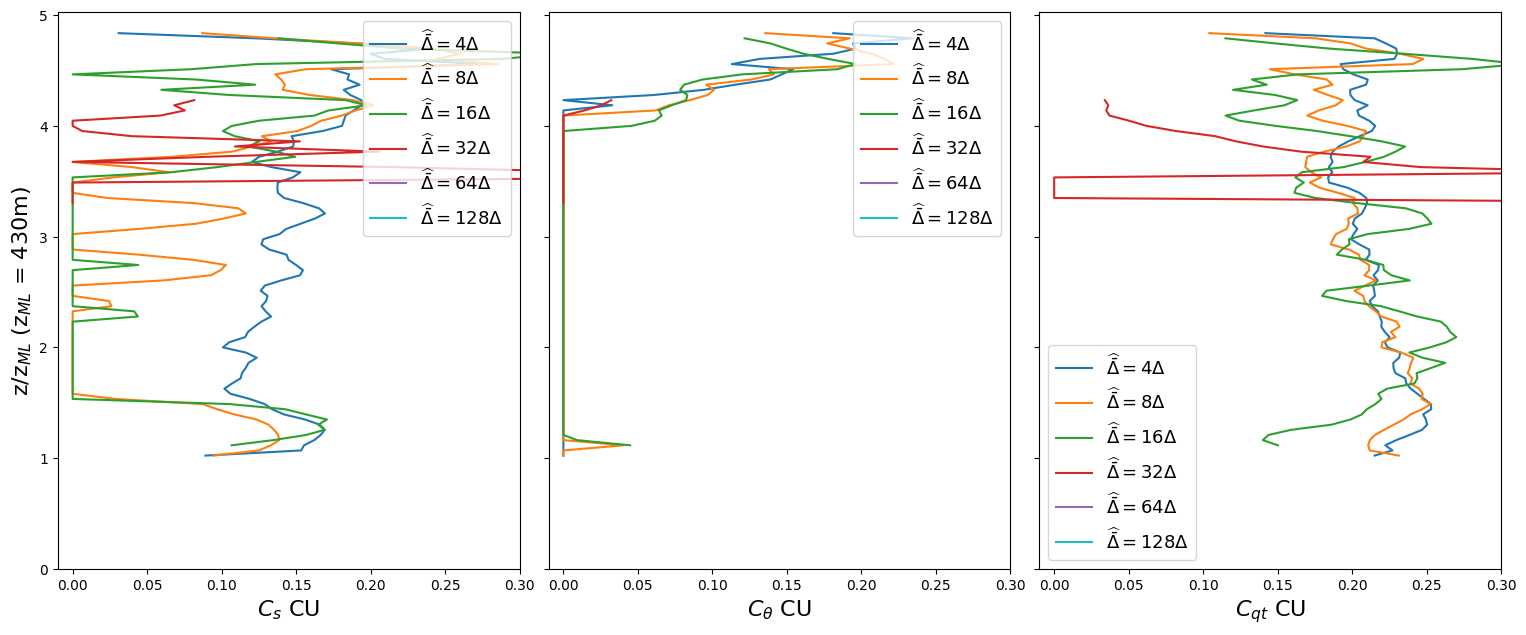

In [19]:
plot_C_all_Deltas(C_sq_BOMEX_0[0,3,...], C_sq_BOMEX_0[1,3,...], C_sq_BOMEX_0[2,3,...], z_BOMEX, z_i_BOMEX, set_labels,
                  'CU', plot_dir_BOMEX, C_type = 'C', set_x_axis = [-0.01, 0.3])

for all Delta profs, min is =  -0.08 max is = 0.1


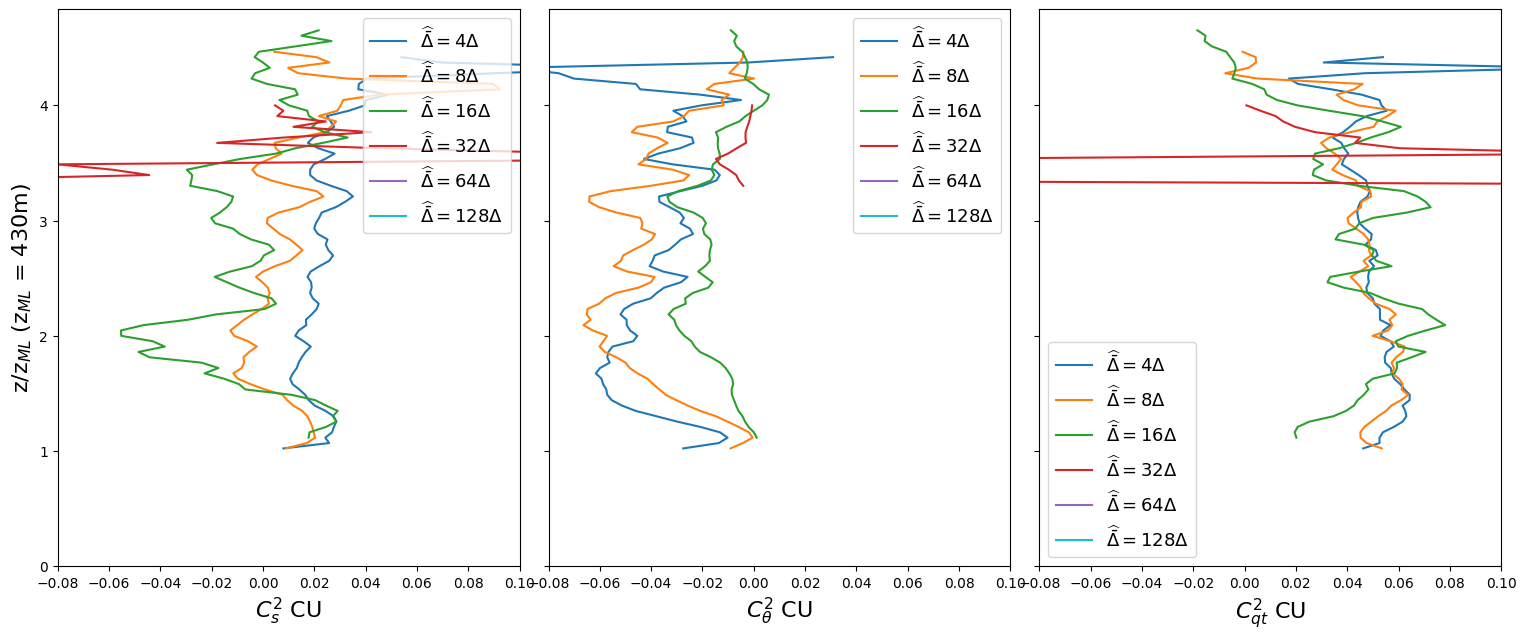

In [20]:
plot_C_all_Deltas(C_sq_BOMEX_0[0,4,...], C_sq_BOMEX_0[1,4,...], C_sq_BOMEX_0[2,4,...], z_BOMEX, z_i_BOMEX,
                  set_labels, 'CU', plot_dir_BOMEX, C_type = 'C_sq', set_x_axis = [-0.08, 0.1])

for all Delta profs, min is =  -0.08 max is = 0.1


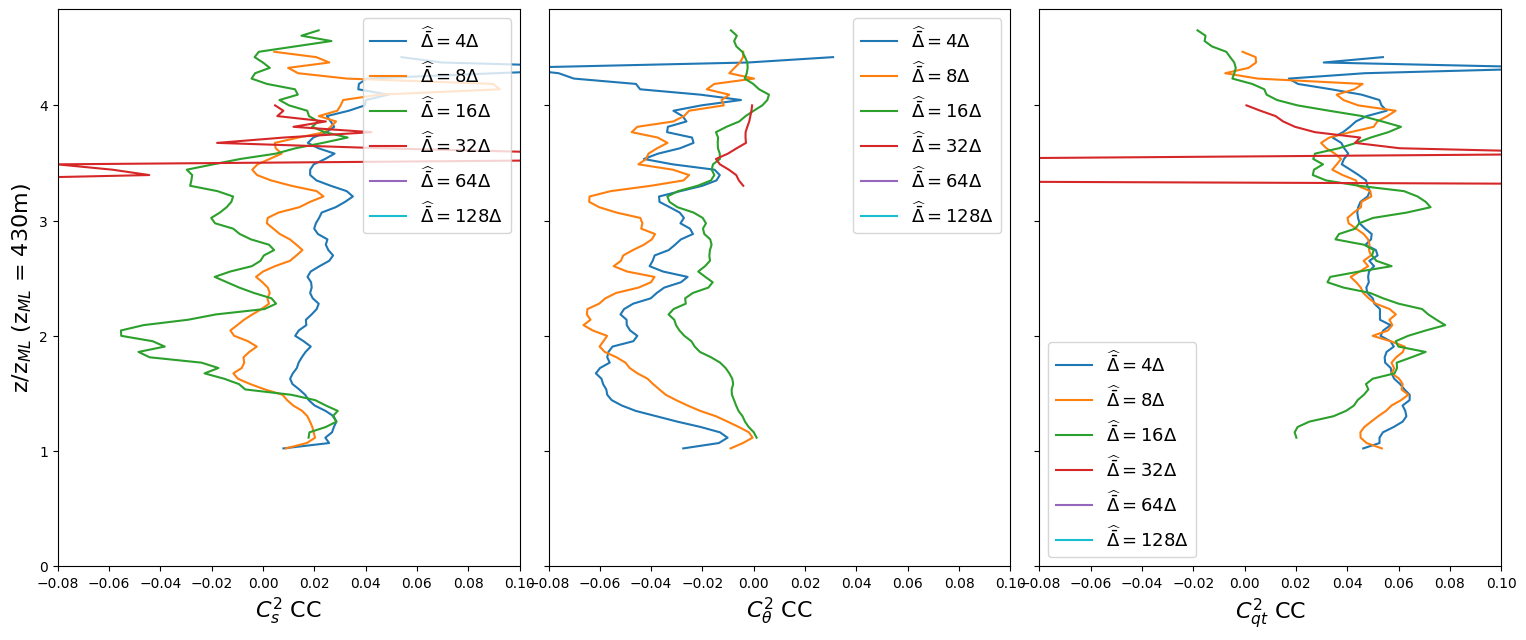

In [21]:
plot_C_all_Deltas(C_sq_BOMEX_0[0,4,...], C_sq_BOMEX_0[1,4,...], C_sq_BOMEX_0[2,4,...], z_BOMEX, z_i_BOMEX, set_labels,
                  'CC', plot_dir_BOMEX, C_type = 'C_sq', set_x_axis = [-0.08, 0.1])

In [22]:
Pr = C_sq_BOMEX_0[0,0,...]/C_sq_BOMEX_0[1,0,...]
Sc = C_sq_BOMEX_0[0,0,...]/C_sq_BOMEX_0[2,0,...]

In [23]:
# Pr[Pr > 2.95] = np.nan
# Pr[Pr < -0.45] = np.nan
#
# Sc[Sc > 2.95] = np.nan
# Sc[Sc < -0.45] = np.nan
#
# Pr = ma.masked_invalid(Pr)
# Sc = ma.masked_invalid(Sc)

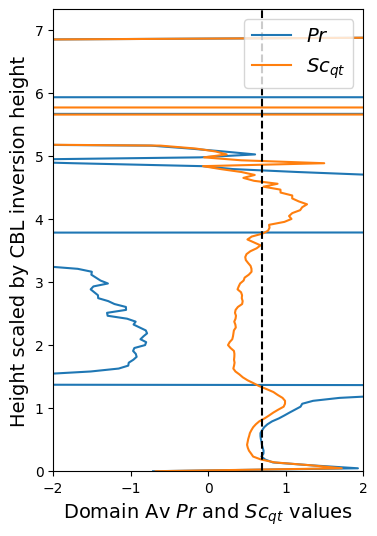

In [24]:
Pr = C_sq_BOMEX_0[0,0,...]/C_sq_BOMEX_0[1,0,...]
Sc = C_sq_BOMEX_0[0,0,...]/C_sq_BOMEX_0[2,0,...]

plt.figure(figsize=(4, 6))
plt.plot(Pr[0, :], z_BOMEX / z_i_BOMEX, label='$Pr$')
plt.plot(Sc[0, :], z_BOMEX / z_i_BOMEX, label='$Sc_{qt}$')
plt.legend(loc='upper right', fontsize=14)
plt.xlabel('Domain Av $Pr$ and $Sc_{qt}$ values', size=14)
plt.ylabel('Height scaled by CBL inversion height', size=14)
bottom0, top0 = plt.ylim()

plt.xlim(-2.0, 2.0)

plt.axvline(0.7, bottom0, top0, color='k', linestyle='dashed')

plt.ylim(0, top0)

plt.savefig(f'{plot_dir_BOMEX}BOMEX_Pr_Sc_domain_20_40.png', bbox_inches='tight')

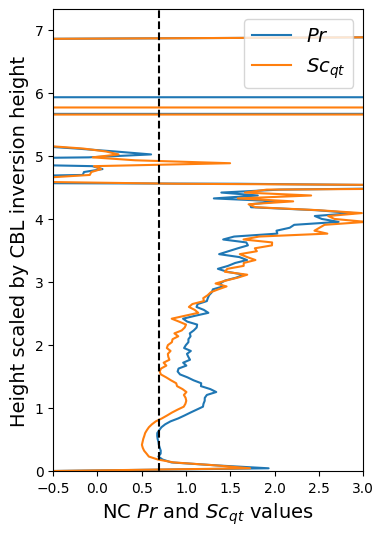

In [25]:
Pr = C_sq_BOMEX_0[0,1,...]/C_sq_BOMEX_0[1,1,...]
Sc = C_sq_BOMEX_0[0,1,...]/C_sq_BOMEX_0[2,1,...]

plt.figure(figsize=(4, 6))
plt.plot(Pr[0, :], z_BOMEX / z_i_BOMEX, label='$Pr$')
plt.plot(Sc[0, :], z_BOMEX / z_i_BOMEX, label='$Sc_{qt}$')
plt.legend(loc='upper right', fontsize=14)
plt.xlabel('NC $Pr$ and $Sc_{qt}$ values', size=14)
plt.ylabel('Height scaled by CBL inversion height', size=14)
bottom0, top0 = plt.ylim()

plt.xlim(-0.5, 3.0)

plt.axvline(0.7, bottom0, top0, color='k', linestyle='dashed')

plt.ylim(0, top0)

plt.savefig(f'{plot_dir_BOMEX}BOMEX_Pr_Sc_NC_20_40.png', bbox_inches='tight')

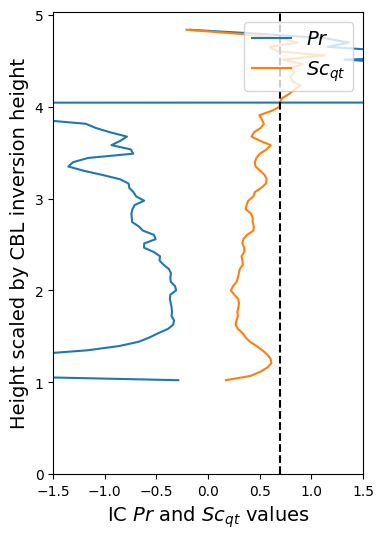

In [26]:
Pr = C_sq_BOMEX_0[0,2,...]/C_sq_BOMEX_0[1,2,...]
Sc = C_sq_BOMEX_0[0,2,...]/C_sq_BOMEX_0[2,2,...]

plt.figure(figsize=(4, 6))
plt.plot(Pr[0, :], z_BOMEX / z_i_BOMEX, label='$Pr$')
plt.plot(Sc[0, :], z_BOMEX / z_i_BOMEX, label='$Sc_{qt}$')
plt.legend(loc='upper right', fontsize=14)
plt.xlabel('IC $Pr$ and $Sc_{qt}$ values', size=14)
plt.ylabel('Height scaled by CBL inversion height', size=14)
bottom0, top0 = plt.ylim()

plt.xlim(-1.5, 1.5)
plt.ylim(bottom = 0)

plt.axvline(0.7, 0, top0, color='k', linestyle='dashed')

plt.ylim(0, top0)

plt.savefig(f'{plot_dir_BOMEX}BOMEX_Pr_Sc_IC_20_40.png', bbox_inches='tight')

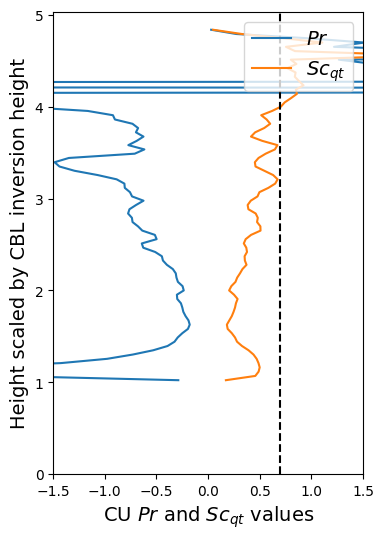

In [27]:
Pr = C_sq_BOMEX_0[0,3,...]/C_sq_BOMEX_0[1,3,...]
Sc = C_sq_BOMEX_0[0,3,...]/C_sq_BOMEX_0[2,3,...]

plt.figure(figsize=(4, 6))
plt.plot(Pr[0, :], z_BOMEX / z_i_BOMEX, label='$Pr$')
plt.plot(Sc[0, :], z_BOMEX / z_i_BOMEX, label='$Sc_{qt}$')
plt.legend(loc='upper right', fontsize=14)
plt.xlabel('CU $Pr$ and $Sc_{qt}$ values', size=14)
plt.ylabel('Height scaled by CBL inversion height', size=14)
bottom0, top0 = plt.ylim()

plt.xlim(-1.5, 1.5)
plt.ylim(bottom = 0)

plt.axvline(0.7, 0, top0, color='k', linestyle='dashed')

plt.ylim(0, top0)

plt.savefig(f'{plot_dir_BOMEX}BOMEX_Pr_Sc_CU_20_40.pdf', bbox_inches='tight')

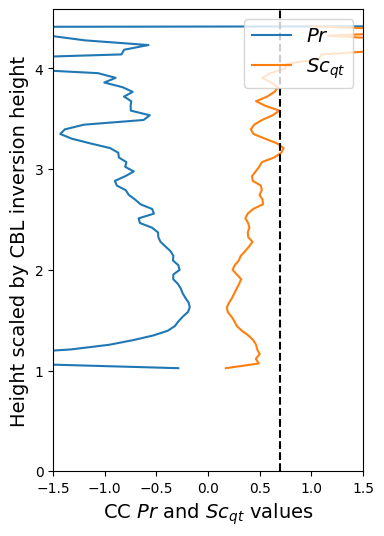

In [28]:
Pr = C_sq_BOMEX_0[0,4,...]/C_sq_BOMEX_0[1,4,...]
Sc = C_sq_BOMEX_0[0,4,...]/C_sq_BOMEX_0[2,4,...]

plt.figure(figsize=(4, 6))
plt.plot(Pr[0, :], z_BOMEX / z_i_BOMEX, label='$Pr$')
plt.plot(Sc[0, :], z_BOMEX / z_i_BOMEX, label='$Sc_{qt}$')
plt.legend(loc='upper right', fontsize=14)
plt.xlabel('CC $Pr$ and $Sc_{qt}$ values', size=14)
plt.ylabel('Height scaled by CBL inversion height', size=14)
bottom0, top0 = plt.ylim()

plt.xlim(-1.5, 1.5)
plt.ylim(bottom = 0)

plt.axvline(0.7, 0, top0, color='k', linestyle='dashed')

plt.ylim(0, top0)

plt.savefig(f'{plot_dir_BOMEX}BOMEX_Pr_Sc_CC_20_40.pdf', bbox_inches='tight')

In [29]:
Cs_sq = np.load(path+f'Cs_sq_cond_32400.npy')[0]
np.shape(Cs_sq)

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/si818415/Documents/code/LES_analysis/data/Cs_sq_cond_32400.npy'

In [ ]:
plt.figure(figsize=(4,6))
plt.plot(get_Cs(Cs_sq)[1,:], z/z_i, label='$\\Delta = 50m$')
plt.plot(get_Cs(Cs_sq)[2,:], z/z_i, label='$\\Delta = 100m$')
plt.plot(sc.savgol_filter(get_Cs(Cs_sq)[3,:], 21, 3), z/z_i, label='$\\Delta = 200m$')
plt.legend(loc='upper right', fontsize=14)
plt.xlabel('$C_s$ value', size=14)
plt.ylabel('Height scaled by CBL inversion height', size=14)
plt.savefig('ARM_C_50_100_200.pdf', bbox_inches='tight')

In [ ]:
def l_mix_MONC(Delta, Cs, z_in, k=0.4):
    l_mix = np.sqrt(1 / ((1 / (Cs * Cs * Delta * Delta)) + (1 / (k * k * z_in * z_in))))

    return l_mix

In [ ]:
plt.figure(figsize=(4,6))
plt.plot(50*get_Cs(Cs_sq)[1,:], z/z_i, '--', label='$\\Delta = 50m$')
plt.plot(100*get_Cs(Cs_sq)[2,:], z/z_i, '--', label='$\\Delta = 100m$')
plt.plot(sc.savgol_filter(200*get_Cs(Cs_sq)[3,:], 51, 3), z/z_i, '--', label='$\\Delta = 200m$')
plt.plot(l_mix_MONC(50, 0.23, z), z/z_i, color='tab:blue')
plt.plot(l_mix_MONC(100, 0.23, z), z/z_i, color='tab:orange')
plt.plot(l_mix_MONC(200, 0.23, z), z/z_i, color='tab:green')
plt.legend(loc='upper right', fontsize=14)
plt.xlabel('Mixing length for momentum', size=14)
plt.ylabel('Height scaled by CBL inversion height', size=14)
plt.savefig('ARM_lmix_50_100_200.pdf', bbox_inches='tight')